# Notebook 3: Hierarchy-Specific EDA

Analyzes how quality score variance is distributed across hierarchical levels (topic, format, URL domain),
and how different filters agree or disagree at each level.

Key analyses:
1. ANOVA-style incremental variance decomposition
2. Cross-filter correlations at topic and format levels
3. URL domain quality heatmap (top 50 domains)
4. Global vs within-topic Spearman rank agreement

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

NB_DIR = Path('.').resolve()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import config

sns.set_theme(style='whitegrid')

FIGURES_DIR = NB_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

def savefig(name):
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()
    plt.close()

TOPIC_NAMES = {
    0: 'Adult', 1: 'Art & Design', 2: 'Software Dev.', 3: 'Crime & Law',
    4: 'Education & Jobs', 5: 'Hardware', 6: 'Entertainment', 7: 'Social Life',
    8: 'Fashion & Beauty', 9: 'Finance & Business', 10: 'Food & Dining',
    11: 'Games', 12: 'Health', 13: 'History', 14: 'Home & Hobbies',
    15: 'Industrial', 16: 'Literature', 17: 'Politics', 18: 'Religion',
    19: 'Science & Tech.', 20: 'Software', 21: 'Sports & Fitness',
    22: 'Transportation', 23: 'Travel'
}

FORMAT_NAMES = {
    0: 'Academic Writing', 1: 'Content Listing', 2: 'Creative Writing',
    3: 'Customer Support', 4: 'Comment Section', 5: 'FAQ', 6: 'Truncated',
    7: 'Knowledge Article', 8: 'Legal Notices', 9: 'Listicle',
    10: 'News Article', 11: 'Nonfiction Writing', 12: 'About (Org.)',
    13: 'News (Org.)', 14: 'About (Pers.)', 15: 'Personal Blog',
    16: 'Product Page', 17: 'Q&A', 18: 'Spam/Ads', 19: 'Structured Data',
    20: 'Documentation', 21: 'Audio Transcript', 22: 'Tutorial', 23: 'User Review'
}

SCORE_DISPLAY = {
    'dclm_score': 'DCLM',
    'fwedu_rounded': 'FWEdu',
    'pc_arc_easy': 'PC-ARC',
    'pc_piqa': 'PC-PIQA',
    'pc_sciq': 'PC-SciQ',
    'pc_lambada_es': 'PC-LAMBADA',
    'qr_writing_style': 'QR-Writing',
    'qr_required_expertise': 'QR-Expertise',
    'qr_facts_and_trivia': 'QR-Facts',
    'qr_educational_value': 'QR-EduVal',
}

HEURISTIC_COLS = [
    'char_count', 'word_count', 'mean_word_length', 'frac_alpha',
    'frac_digit', 'frac_punctuation', 'frac_uppercase', 'frac_lines_terminal_punct',
    'frac_lines_bullet', 'type_token_ratio', 'stopword_fraction',
    'ngram_rep_2', 'ngram_rep_3', 'ngram_rep_4',
    'num_lines', 'mean_line_length'
]

# Load master
df = pd.read_parquet(config.MASTER_PARQUET)
print(f'Loaded {len(df):,} documents, {df.shape[1]} columns')

ALL_SCORE_COLS = [
    'dclm_score', 'fwedu_rounded',
    'pc_arc_easy', 'pc_piqa', 'pc_sciq', 'pc_lambada_es',
    'qr_writing_style', 'qr_required_expertise', 'qr_facts_and_trivia', 'qr_educational_value'
]
ALL_SCORE_COLS = [c for c in ALL_SCORE_COLS if c in df.columns]
coverage = df[ALL_SCORE_COLS].notna().mean()
GOOD_SCORES = [c for c in ALL_SCORE_COLS if coverage[c] >= 0.10]
HEURISTIC_COLS = [c for c in HEURISTIC_COLS if c in df.columns]
print(f'Good scores (>=10% coverage): {GOOD_SCORES}')
print(f'Heuristic features available: {len(HEURISTIC_COLS)}')

Loaded 2,263,456 documents, 56 columns
Good scores (>=10% coverage): ['dclm_score', 'fwedu_rounded', 'pc_arc_easy', 'pc_piqa', 'pc_sciq', 'pc_lambada_es', 'qr_writing_style', 'qr_required_expertise', 'qr_facts_and_trivia', 'qr_educational_value']
Heuristic features available: 16


In [2]:
# --- Cell 2: ANOVA-style incremental variance decomposition ---
# For each quality score, fit OLS models of increasing complexity:
#   (a) topic only
#   (b) topic + format
#   (c) topic + format + top-50 URL domains
#   (d) topic + format + top-50 URL domains + heuristic features
# Report incremental R^2 at each step.

N_DECOMP = min(200_000, len(df))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df), size=N_DECOMP, replace=False)
sample = df.iloc[sample_idx].copy().reset_index(drop=True)
print(f'Using {N_DECOMP:,} documents for variance decomposition')

# Identify top-50 URL domains
domain_col = 'url_registered_domain' if 'url_registered_domain' in df.columns else 'url_netloc'
top50_domains = df[domain_col].value_counts().head(50).index.tolist()
# Create a binary dummy column for top domains in sample
sample['domain_top50'] = sample[domain_col].where(sample[domain_col].isin(top50_domains), other='__other__')

def fit_ols_r2(X, y):
    """Fit OLS via lstsq (with intercept) and return R^2."""
    # Add intercept
    Xc = np.column_stack([np.ones(len(X)), X])
    coef, _, _, _ = np.linalg.lstsq(Xc, y, rcond=None)
    y_hat = Xc @ coef
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

results = {}  # score -> dict of r2 levels

for score in GOOD_SCORES:
    sub = sample[['topic', 'format', 'domain_top50', score] + HEURISTIC_COLS].dropna(subset=[score])
    if len(sub) < 500:
        print(f'Skipping {score}: too few non-NaN rows ({len(sub)})')
        continue
    y = sub[score].values.astype(float)

    # (a) topic only
    X_topic = pd.get_dummies(sub['topic'].astype(str), drop_first=True).values.astype(float)
    r2_topic = fit_ols_r2(X_topic, y)

    # (b) topic + format
    X_format = pd.get_dummies(sub['format'].astype(str), drop_first=True).values.astype(float)
    X_tf = np.column_stack([X_topic, X_format])
    r2_tf = fit_ols_r2(X_tf, y)

    # (c) topic + format + top50 domains
    X_dom = pd.get_dummies(sub['domain_top50'], drop_first=True).values.astype(float)
    X_tfd = np.column_stack([X_tf, X_dom])
    r2_tfd = fit_ols_r2(X_tfd, y)

    # (d) topic + format + top50 domains + heuristics
    heur_available = [c for c in HEURISTIC_COLS if c in sub.columns]
    if heur_available:
        X_heur = sub[heur_available].fillna(0).values.astype(float)
        X_full = np.column_stack([X_tfd, X_heur])
        r2_full = fit_ols_r2(X_full, y)
    else:
        r2_full = r2_tfd

    results[score] = {
        'Topic': r2_topic,
        '+ Format': r2_tf - r2_topic,
        '+ Top-50 Domains': r2_tfd - r2_tf,
        '+ Heuristics': r2_full - r2_tfd,
        'Unexplained': 1.0 - r2_full,
    }
    print(f'{score}: R2_topic={r2_topic:.3f}, R2_+fmt={r2_tf:.3f}, '
          f'R2_+dom={r2_tfd:.3f}, R2_full={r2_full:.3f}')

r2_df = pd.DataFrame(results).T
r2_df.index = [SCORE_DISPLAY.get(c, c) for c in r2_df.index]
print('\nVariance decomposition table:')
display(r2_df.round(3))

Using 200,000 documents for variance decomposition


dclm_score: R2_topic=0.016, R2_+fmt=0.050, R2_+dom=0.063, R2_full=0.082


fwedu_rounded: R2_topic=0.211, R2_+fmt=0.319, R2_+dom=0.320, R2_full=0.409


pc_arc_easy: R2_topic=0.082, R2_+fmt=0.114, R2_+dom=0.122, R2_full=0.147


pc_piqa: R2_topic=0.062, R2_+fmt=0.104, R2_+dom=0.118, R2_full=0.142


...

qr_writing_style: R2_topic=0.153, R2_+fmt=0.371, R2_+dom=0.377, R2_full=0.552


qr_required_expertise: R2_topic=0.323, R2_+fmt=0.439, R2_+dom=0.443, R2_full=0.624


qr_facts_and_trivia: R2_topic=0.234, R2_+fmt=0.412, R2_+dom=0.415, R2_full=0.526


qr_educational_value: R2_topic=0.321, R2_+fmt=0.446, R2_+dom=0.450, R2_full=0.592

Variance decomposition table:


,Topic,+ Format,+ Top-50 Domains,+ Heuristics,Unexplained
DCLM,0.016,0.034,0.012,0.019,0.918
FWEdu,0.211,0.108,0.002,0.088,0.591
PC-ARC,0.082,0.031,0.008,0.025,0.853
PC-PIQA,0.062,0.042,0.014,0.024,0.858
PC-SciQ,0.145,0.043,0.010,0.034,0.768
PC-LAMBADA,0.157,0.069,0.003,0.036,0.735
QR-Writing,0.153,0.218,0.006,0.175,0.448
QR-Expertise,0.323,0.117,0.004,0.180,0.376
QR-Facts,0.234,0.178,0.003,0.112,0.474
QR-EduVal,0.321,0.125,0.004,0.142,0.408


Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\03_variance_decomposition.png


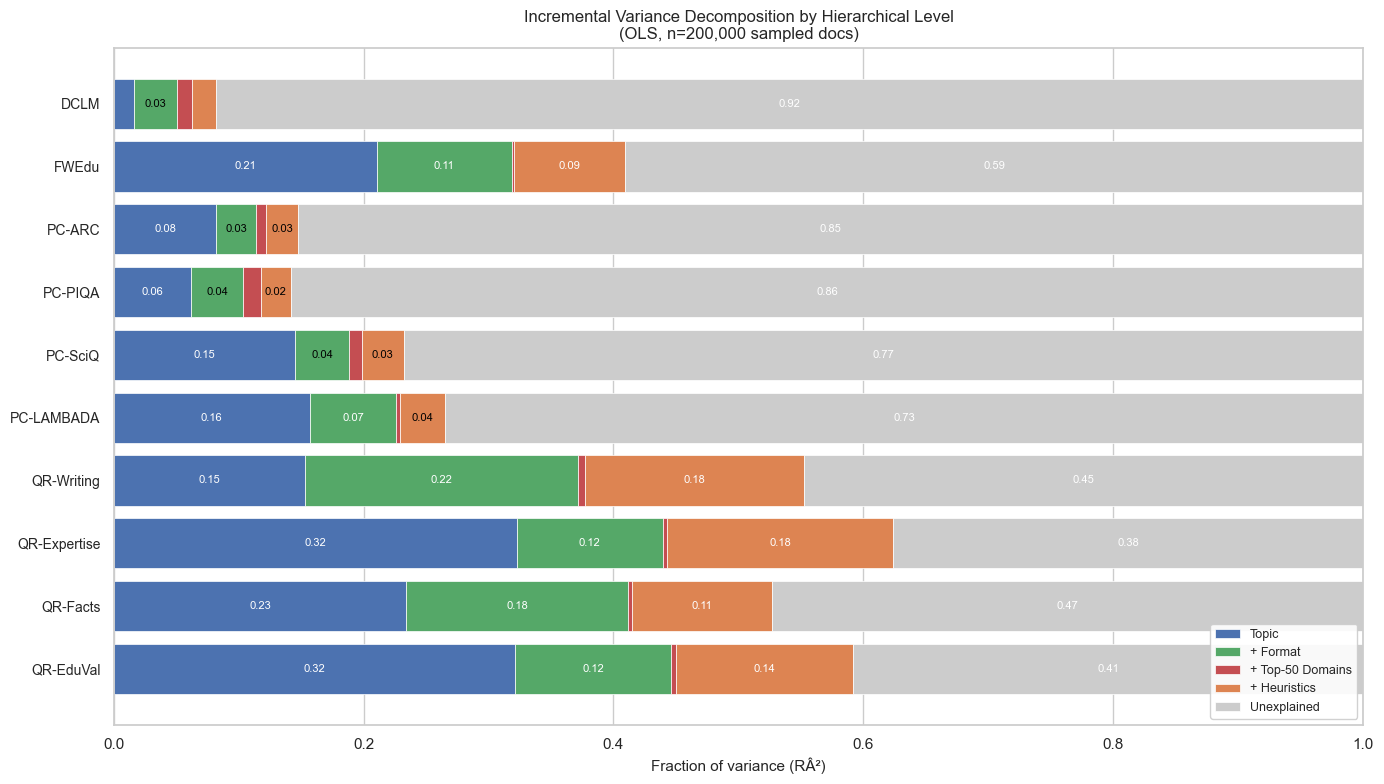

In [3]:
# Plot variance decomposition as stacked horizontal bar chart

level_colors = {
    'Topic': '#4C72B0',
    '+ Format': '#55A868',
    '+ Top-50 Domains': '#C44E52',
    '+ Heuristics': '#DD8452',
    'Unexplained': '#CCCCCC',
}

fig, ax = plt.subplots(figsize=(14, max(5, len(r2_df) * 0.6 + 2)))

y_pos = np.arange(len(r2_df))
lefts = np.zeros(len(r2_df))

for level, color in level_colors.items():
    if level not in r2_df.columns:
        continue
    widths = r2_df[level].values
    bars = ax.barh(y_pos, widths, left=lefts, color=color, label=level, edgecolor='white', linewidth=0.5)
    # Annotate bar segments > 2%
    for bar, left, w in zip(bars, lefts, widths):
        if w > 0.02:
            ax.text(
                left + w / 2, bar.get_y() + bar.get_height() / 2,
                f'{w:.2f}', va='center', ha='center', fontsize=8, color='white' if w > 0.05 else 'black'
            )
    lefts += widths

ax.set_yticks(y_pos)
ax.set_yticklabels(r2_df.index, fontsize=10)
ax.set_xlabel('Fraction of variance (RÂ²)', fontsize=11)
ax.set_xlim(0, 1)
ax.set_title(
    f'Incremental Variance Decomposition by Hierarchical Level\n'
    f'(OLS, n={N_DECOMP:,} sampled docs)',
    fontsize=12
)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.invert_yaxis()

savefig('03_variance_decomposition.png')

Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\03_crossfilter_topic_correlation.png


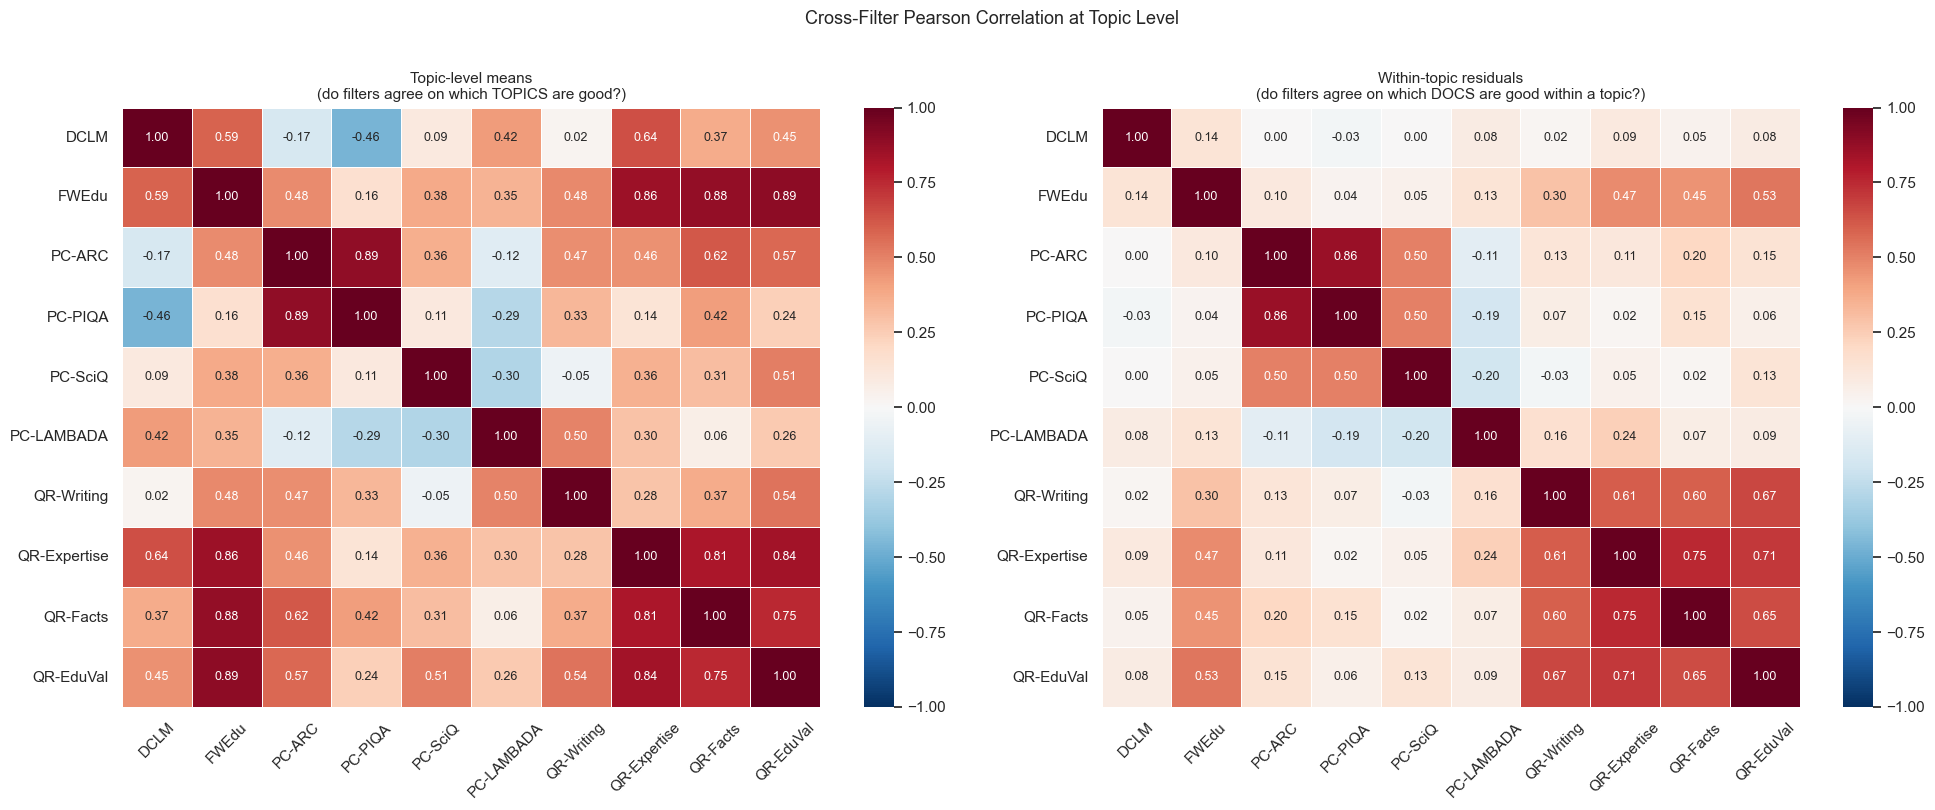

In [4]:
# --- Cell 3: Cross-filter correlations at topic and format levels ---

def compute_level_corr(df_in, group_col, scores):
    """Compute topic/format-level mean of each score, then correlate across filters."""
    means = df_in.groupby(group_col)[scores].mean()
    return means.corr(method='pearson')

def compute_within_residuals(df_in, group_col, scores):
    """Subtract group mean from each doc score, then correlate residuals."""
    resid = df_in[scores + [group_col]].copy()
    for sc in scores:
        group_means = df_in.groupby(group_col)[sc].transform('mean')
        resid[sc] = resid[sc] - group_means
    return resid[scores].corr(method='pearson')

score_labels = [SCORE_DISPLAY.get(c, c) for c in GOOD_SCORES]

# --- Topic level ---
topic_mean_corr = compute_level_corr(df, 'topic', GOOD_SCORES)
topic_resid_corr = compute_within_residuals(df, 'topic', GOOD_SCORES)

topic_mean_corr.index = score_labels
topic_mean_corr.columns = score_labels
topic_resid_corr.index = score_labels
topic_resid_corr.columns = score_labels

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, mat, title in zip(
    axes,
    [topic_mean_corr, topic_resid_corr],
    ['Topic-level means\n(do filters agree on which TOPICS are good?)',
     'Within-topic residuals\n(do filters agree on which DOCS are good within a topic?)']
):
    sns.heatmap(
        mat, ax=ax, annot=True, fmt='.2f',
        cmap='RdBu_r', vmin=-1, vmax=1,
        linewidths=0.5, annot_kws={'size': 9}
    )
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Cross-Filter Pearson Correlation at Topic Level', fontsize=13, y=1.01)
savefig('03_crossfilter_topic_correlation.png')

Documents in top-50 domains: 249,830


Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\03_domain_heatmap.png


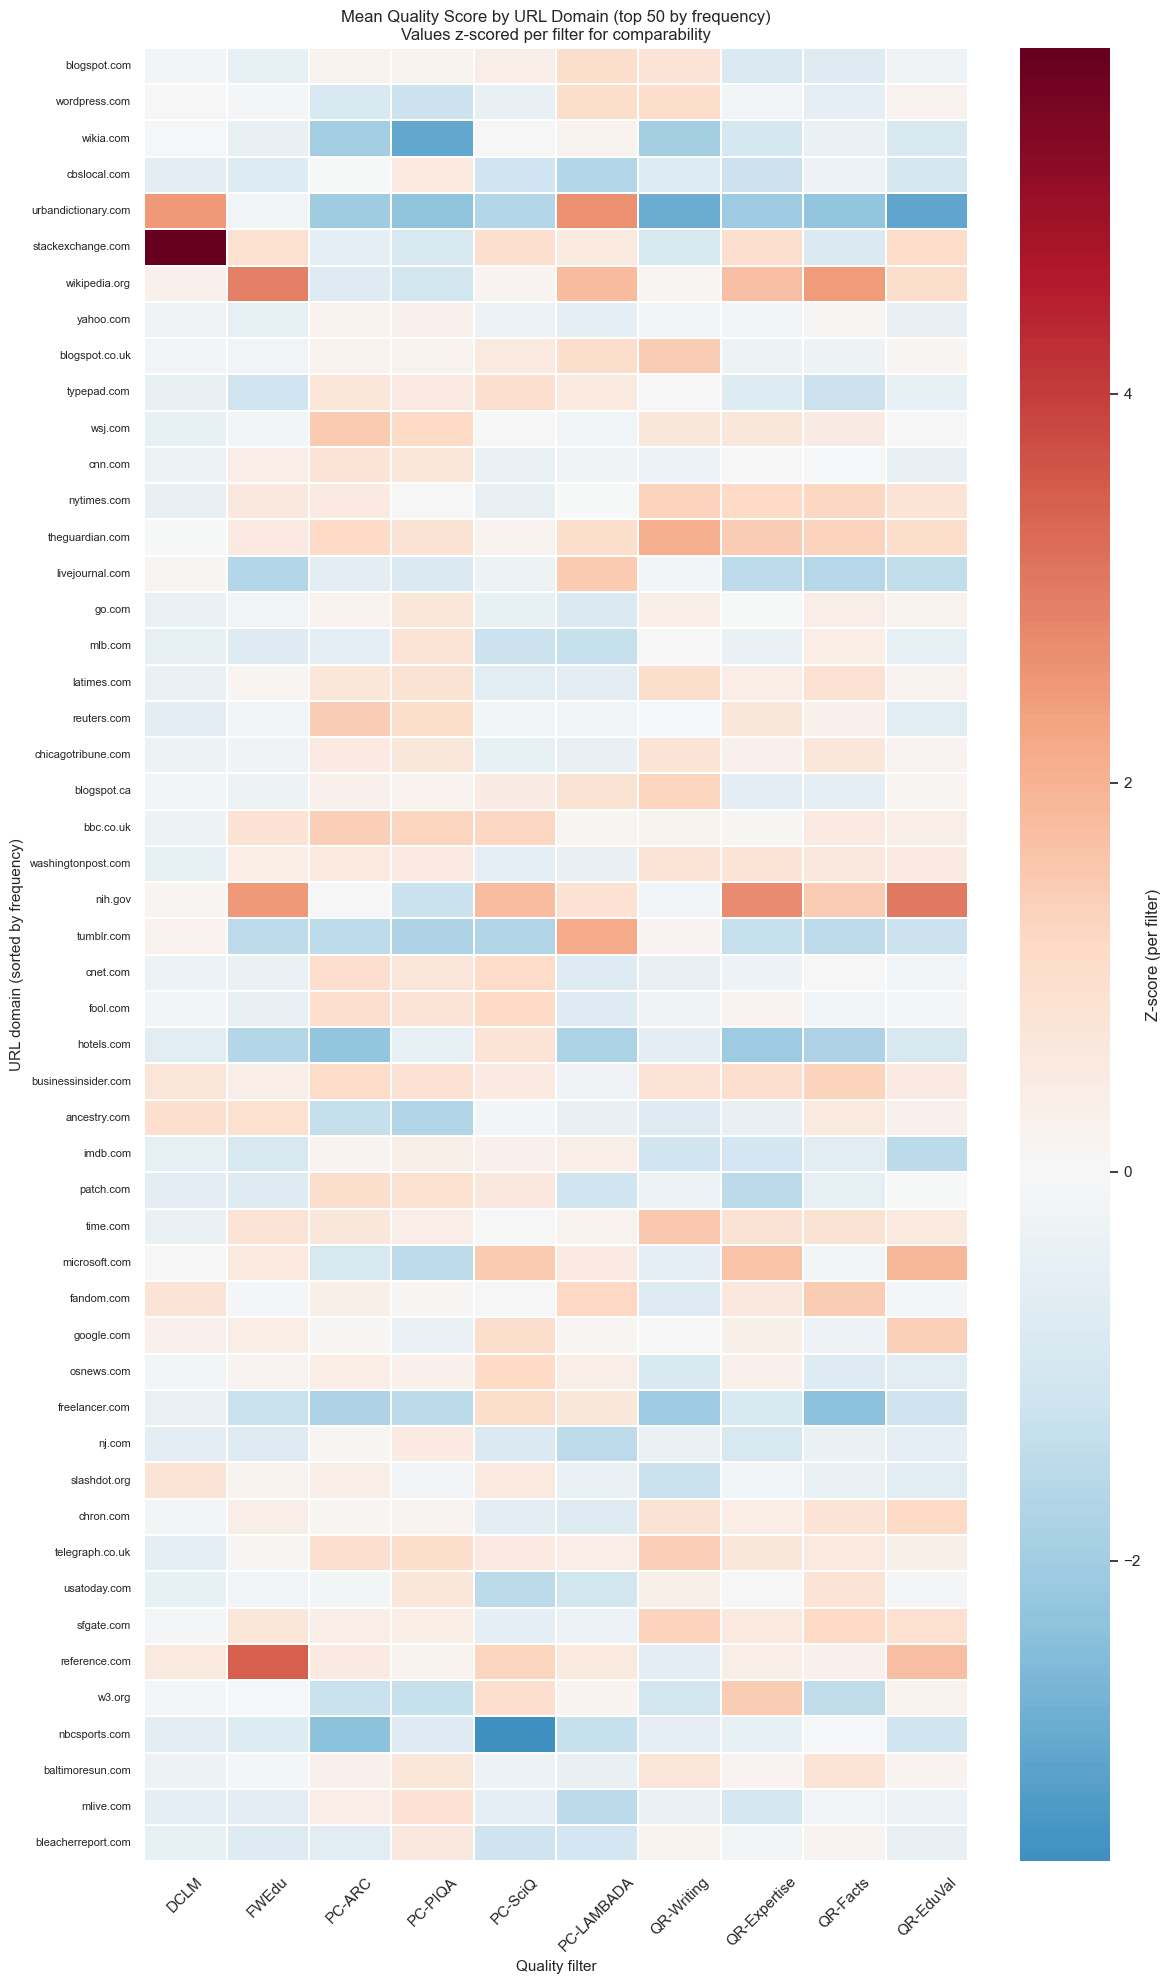

In [5]:
# --- Cell 4: URL domain heatmap (top 50 domains) ---

domain_col = 'url_registered_domain' if 'url_registered_domain' in df.columns else 'url_netloc'
top50 = df[domain_col].value_counts().head(50).index.tolist()

dom_sub = df[df[domain_col].isin(top50)].copy()
print(f'Documents in top-50 domains: {len(dom_sub):,}')

# Mean score per domain, for each good score
dom_means = dom_sub.groupby(domain_col)[GOOD_SCORES].mean()
# Sort by descending document count
dom_order = df[domain_col].value_counts().head(50).index
dom_means = dom_means.reindex(dom_order).dropna(how='all')

# Z-score each score column for comparable color scale
dom_z = (dom_means - dom_means.mean()) / dom_means.std()
dom_z.columns = [SCORE_DISPLAY.get(c, c) for c in dom_z.columns]

fig, ax = plt.subplots(figsize=(max(10, len(GOOD_SCORES) * 1.2), min(20, len(dom_z) * 0.45 + 2)))
sns.heatmap(
    dom_z,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    linewidths=0.3,
    yticklabels=True,
    cbar_kws={'label': 'Z-score (per filter)'}
)
ax.set_xlabel('Quality filter', fontsize=11)
ax.set_ylabel('URL domain (sorted by frequency)', fontsize=11)
ax.set_title(
    f'Mean Quality Score by URL Domain (top 50 by frequency)\n'
    f'Values z-scored per filter for comparability',
    fontsize=12
)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', labelsize=8)

savefig('03_domain_heatmap.png')

Computing Spearman correlations on 50,000 sampled docs


Saved: C:\Angikar\ANGIKAR_STANFORD\SECOND_YEAR\SPRING_2026\Courses\STATS_305C\WebOrganizer\milestone2\figures\03_spearman_rank.png


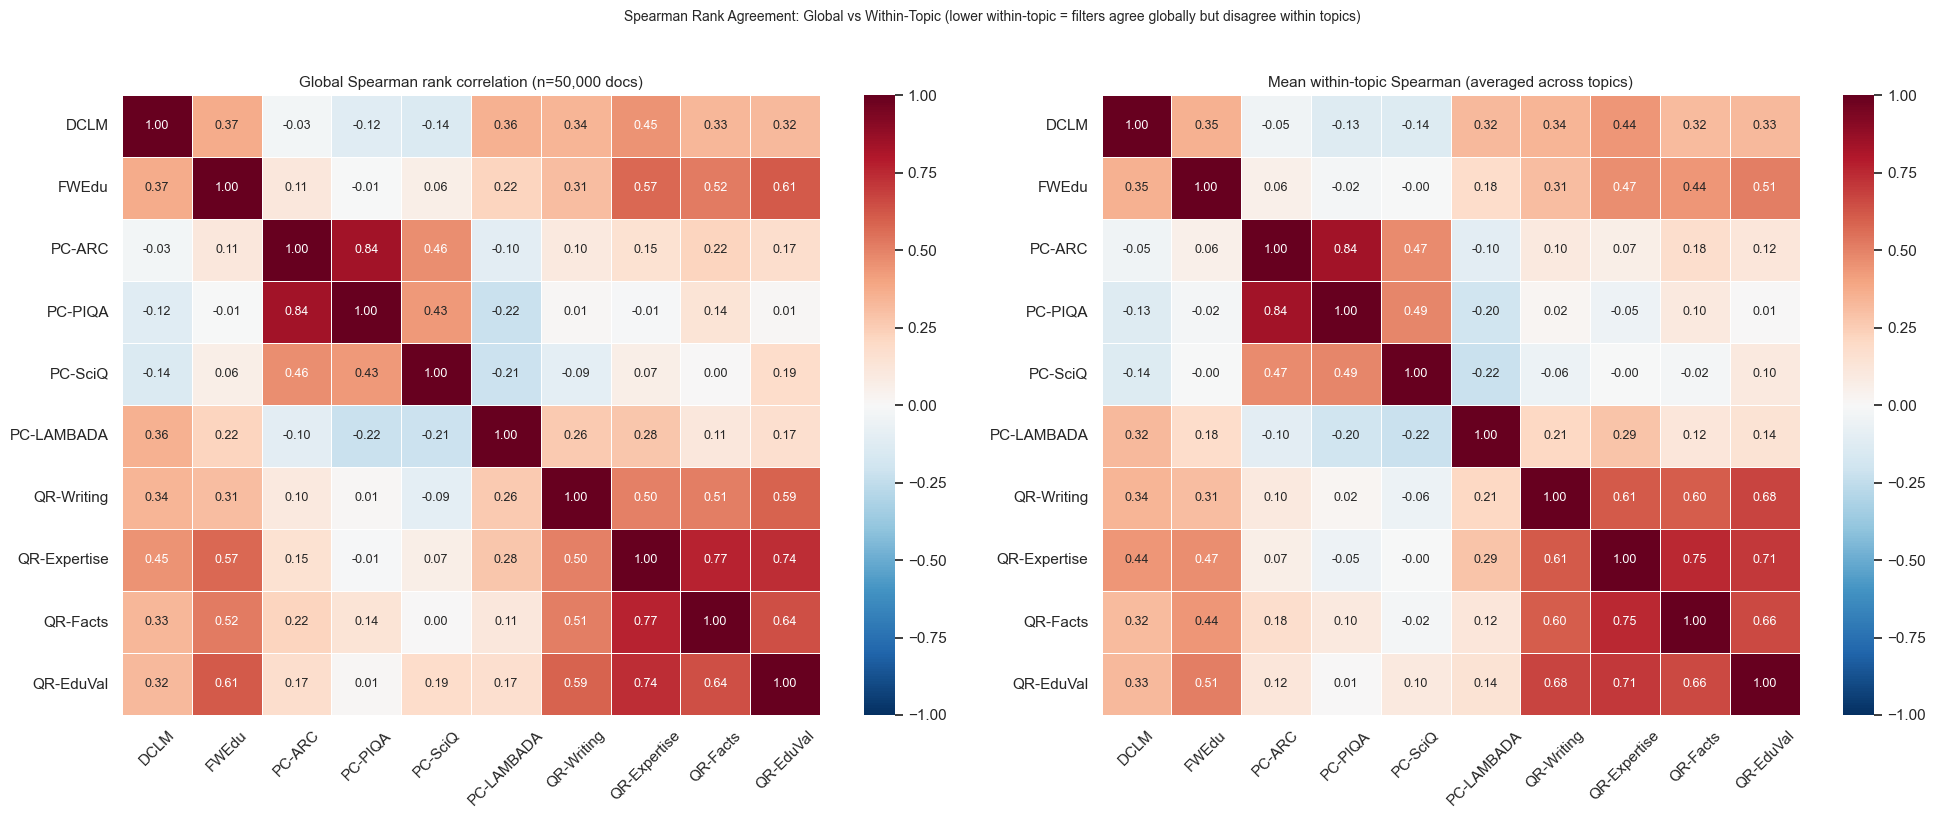

Top pairs by drop in rank agreement (global -> within-topic):
      filter_A      filter_B  global_r  within_topic_r   drop
14       FWEdu  QR-Expertise     0.575           0.468  0.107
16       FWEdu     QR-EduVal     0.611           0.512  0.098
34     PC-SciQ     QR-EduVal     0.186           0.097  0.089
21      PC-ARC  QR-Expertise     0.153           0.070  0.083
15       FWEdu      QR-Facts     0.523           0.444  0.079
32     PC-SciQ  QR-Expertise     0.068          -0.003  0.071
11       FWEdu       PC-SciQ     0.064          -0.000  0.064
35  PC-LAMBADA    QR-Writing     0.263           0.209  0.055
9        FWEdu        PC-ARC     0.112           0.059  0.053
23      PC-ARC     QR-EduVal     0.172           0.121  0.051


In [6]:
# --- Cell 5: Spearman rank agreement (global vs within-topic) ---

N_RANK = min(50_000, len(df))
rng3 = np.random.default_rng(99)
rank_idx = rng3.choice(len(df), size=N_RANK, replace=False)
rank_sample = df.iloc[rank_idx].copy().reset_index(drop=True)
print(f'Computing Spearman correlations on {N_RANK:,} sampled docs')

n_s = len(GOOD_SCORES)
global_spearman = np.full((n_s, n_s), np.nan)
within_topic_spearman = np.full((n_s, n_s), np.nan)

for i, s1 in enumerate(GOOD_SCORES):
    for j, s2 in enumerate(GOOD_SCORES):
        if i >= j:  # skip diagonal (fill with 1.0 below) and lower triangle
            continue
        sub = rank_sample[['topic', s1, s2]].dropna()
        if len(sub) < 50:
            continue
        r_global = float(sub[s1].corr(sub[s2], method='spearman'))
        global_spearman[i, j] = r_global
        global_spearman[j, i] = r_global
        topic_rs = []
        for t, grp in sub.groupby('topic'):
            if len(grp) >= 10:
                r_t = float(grp[s1].corr(grp[s2], method='spearman'))
                if not np.isnan(r_t):
                    topic_rs.append(r_t)
        if topic_rs:
            r_within = float(np.mean(topic_rs))
            within_topic_spearman[i, j] = r_within
            within_topic_spearman[j, i] = r_within

np.fill_diagonal(global_spearman, 1.0)
np.fill_diagonal(within_topic_spearman, 1.0)

labels_sp = [SCORE_DISPLAY.get(c, c) for c in GOOD_SCORES]
global_df = pd.DataFrame(global_spearman, index=labels_sp, columns=labels_sp)
within_df = pd.DataFrame(within_topic_spearman, index=labels_sp, columns=labels_sp)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
titles = [
    'Global Spearman rank correlation (n={:,} docs)'.format(N_RANK),
    'Mean within-topic Spearman (averaged across topics)',
]
for ax, mat, title in zip(axes, [global_df, within_df], titles):
    sns.heatmap(mat, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
fig.suptitle(
    'Spearman Rank Agreement: Global vs Within-Topic '
    '(lower within-topic = filters agree globally but disagree within topics)',
    fontsize=10, y=1.02
)
savefig('03_spearman_rank.png')

diff = global_df - within_df
diff_flat = []
for i, r in enumerate(labels_sp):
    for j, c in enumerate(labels_sp):
        if i < j:
            diff_flat.append({'filter_A': r, 'filter_B': c,
                              'global_r': global_df.iloc[i, j],
                              'within_topic_r': within_df.iloc[i, j],
                              'drop': diff.iloc[i, j]})
diff_table = pd.DataFrame(diff_flat).sort_values('drop', ascending=False)
print('Top pairs by drop in rank agreement (global -> within-topic):')
print(diff_table.head(10).round(3).to_string())
